<a href="https://colab.research.google.com/github/esprydi/sentimen-analisis-shopee-playstore/blob/master/Processing_Sentiment_Analisis_shopee_Playstore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install necessary packages
!pip install sastrawi
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 48.7 MB/s eta 0:00:00


In [2]:
# Download NLTK data
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import torch
import lightgbm as lgb

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from wordcloud import WordCloud
from sklearn.metrics import accuracy_score
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification, AutoModel
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter
from gensim.models import Word2Vec
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

pd.options.mode.chained_assignment = None
seed = 0
np.random.seed(seed)

# Loading Dataset

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd

# Pastikan Google Drive sudah terpasang (mounted) dengan menjalankan kode mount drive di sel terpisah.
output_path = '/content/drive/MyDrive/shopee_app_reviews.csv'

# Membaca DataFrame dari file CSV di Google Drive
try:
    app_reviews_df = pd.read_csv(output_path)
    print(f"Data ulasan berhasil dibaca dari: {output_path}")
except FileNotFoundError:
    print(f"Error: File tidak ditemukan di {output_path}. Pastikan file sudah tersimpan di Google Drive Anda.")
    app_reviews_df = pd.DataFrame() # Membuat DataFrame kosong sebagai fallback jika file tidak ditemukan

# Menghitung jumlah baris dan kolom dalam DataFrame
jumlah_ulasan, jumlah_kolom = app_reviews_df.shape

# Menampilkan hasil
print(f"Jumlah ulasan: {jumlah_ulasan}")

# Menampilkan lima baris pertama untuk verifikasi
print("\nLima baris pertama DataFrame setelah dibaca:")
display(app_reviews_df.head())

Data ulasan berhasil dibaca dari: /content/drive/MyDrive/shopee_app_reviews.csv
Jumlah ulasan: 20000

Lima baris pertama DataFrame setelah dibaca:


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,675d7447-9df2-4eba-85b4-24660d842bb5,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Asli keamanannya bagus, aman juga lancar semua...",5,5,3.68.42,2026-03-03 12:39:10,"Hi kak misterius_, makasih ya buat review bint...",2026-03-03 14:25:07,3.68.42
1,e5fa64c2-fcee-429e-8775-0644f584a59b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Top,Saya sangat suka belanja disini selain ban...",5,2,3.68.42,2026-03-10 07:31:47,"Hi kak Pipi Papi, maaf ya sudah buat kmu gak n...",2026-03-10 08:21:09,3.68.42
2,faa9dab8-1efb-4209-80b8-2cbdbcd152e9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Banyak error, ya ampun lemot banget terutama b...",2,1,3.68.42,2026-03-09 11:56:59,"Hai kak Terrysha Cindy Auxilia, makasih ya bua...",2026-03-09 12:48:10,3.68.42
3,9bb6cc1b-6d4c-4c2e-9a9e-97bd14b7125d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"sistem sering error, saat mesan secara sengaja...",1,0,3.69.34,2026-03-13 08:43:09,"Hai kak Aikawa Miku , terima kasih ya untuk fe...",2026-03-13 09:07:47,3.69.34
4,246efb4d-c63f-4c06-9b30-4fc8dcb8a0e0,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,koneksinya padahal bagus tapi susah banget bua...,5,5,3.68.42,2026-03-06 03:37:59,"Hi Kak Misaki Yuki, maaf ya udah bikin Kakak g...",2026-03-06 06:50:38,3.68.42


In [7]:
# Menampilkan lima baris pertama
app_reviews_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,675d7447-9df2-4eba-85b4-24660d842bb5,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Asli keamanannya bagus, aman juga lancar semua...",5,5,3.68.42,2026-03-03 12:39:10,"Hi kak misterius_, makasih ya buat review bint...",2026-03-03 14:25:07,3.68.42
1,e5fa64c2-fcee-429e-8775-0644f584a59b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Top,Saya sangat suka belanja disini selain ban...",5,2,3.68.42,2026-03-10 07:31:47,"Hi kak Pipi Papi, maaf ya sudah buat kmu gak n...",2026-03-10 08:21:09,3.68.42
2,faa9dab8-1efb-4209-80b8-2cbdbcd152e9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Banyak error, ya ampun lemot banget terutama b...",2,1,3.68.42,2026-03-09 11:56:59,"Hai kak Terrysha Cindy Auxilia, makasih ya bua...",2026-03-09 12:48:10,3.68.42
3,9bb6cc1b-6d4c-4c2e-9a9e-97bd14b7125d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"sistem sering error, saat mesan secara sengaja...",1,0,3.69.34,2026-03-13 08:43:09,"Hai kak Aikawa Miku , terima kasih ya untuk fe...",2026-03-13 09:07:47,3.69.34
4,246efb4d-c63f-4c06-9b30-4fc8dcb8a0e0,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,koneksinya padahal bagus tapi susah banget bua...,5,5,3.68.42,2026-03-06 03:37:59,"Hi Kak Misaki Yuki, maaf ya udah bikin Kakak g...",2026-03-06 06:50:38,3.68.42


In [8]:
# Menampilkan informasi
app_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              20000 non-null  object
 1   userName              20000 non-null  object
 2   userImage             20000 non-null  object
 3   content               20000 non-null  object
 4   score                 20000 non-null  int64 
 5   thumbsUpCount         20000 non-null  int64 
 6   reviewCreatedVersion  19853 non-null  object
 7   at                    20000 non-null  object
 8   replyContent          18714 non-null  object
 9   repliedAt             18714 non-null  object
 10  appVersion            19853 non-null  object
dtypes: int64(2), object(9)
memory usage: 1.7+ MB


In [9]:
# Membuat DataFrame baru dengan menghapus baris yang memiliki nilai yang hilang

clean_df = app_reviews_df.dropna()

In [10]:
# Menghapus baris duplikat
clean_df = clean_df.drop_duplicates()

# Menghitung jumlah baris dan kolom dalam DataFrame clean_df setelah menghapus duplikat
jumlah_ulasan,jumlah_kolom = clean_df.shape

clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18573 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              18573 non-null  object
 1   userName              18573 non-null  object
 2   userImage             18573 non-null  object
 3   content               18573 non-null  object
 4   score                 18573 non-null  int64 
 5   thumbsUpCount         18573 non-null  int64 
 6   reviewCreatedVersion  18573 non-null  object
 7   at                    18573 non-null  object
 8   replyContent          18573 non-null  object
 9   repliedAt             18573 non-null  object
 10  appVersion            18573 non-null  object
dtypes: int64(2), object(9)
memory usage: 1.7+ MB


# Preprocessing Text

In [11]:
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# --- 1. INISIALISASI ---
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
    text = re.sub(r'RT[\s]', '', text) # menghapus RT
    text = re.sub(r"http\S+", '', text) # menghapus link
    text = re.sub(r'[0-9]+', '', text) # menghapus angka
    text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka
    text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
    text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
    return text

def casefoldingText(text): # Mengubah semua karakter dalam teks menjadi huruf kecil
    text = text.lower()
    return text

def tokenizingText(text): # Memecah atau membagi string, teks menjadi daftar token
    text = word_tokenize(text)
    return text

def filteringText(text_tokens): # Menghapus stopwords dalam teks
    # Ambil stopwords dasar
    listStopwords = set(stopwords.words('indonesian'))
    # --- PENYELAMATAN NEGASI ---
    # Daftar kata yang TIDAK BOLEH dihapus karena penting untuk makna negatif
    negasi_penting = {"tidak", "bukan", "kurang", "jangan", "ga", "gak", "nggak"}
    for kata in negasi_penting:
        if kata in listStopwords:
            listStopwords.remove(kata)
    # Tambahkan kata-kata sampah spesifik Shopee/Playstore
    listStopwords.update(['dan', 'saya', 'dll', 'dkk', 'dsb', 'dst', 'yg', 'itu', 'ini',
        'adalah', 'ya', 'kak', 'shopee', 'aplikasi', 'nya', 'sih'])    # Filter: Simpan kata jika TIDAK ada di listStopwords ATAU mengandung "_"
    filtered = [w for w in text_tokens if (w not in listStopwords) or ("_" in w)]

    return filtered # Mengembalikan list, bukan string

# Buat kamus kosong untuk menyimpan kata yang sudah di-stem
stem_cache = {}

def stemmingText(text):
    words = text.split()
    stemmed_words = []

    for word in words:
        if word not in stem_cache:
            # Jika kata belum pernah di-stem, hitung dan simpan ke cache
            stem_cache[word] = stemmer.stem(word)
        stemmed_words.append(stem_cache[word])

    return ' '.join(stemmed_words)

def toSentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence

def reduce_lengthening(text): # Normalisasi karakter berulang misal : bagusss jadi bagus
    pattern = re.compile(r"(.)\1{2,}")
    return pattern.sub(r"\1\1", text)

def handle_negation(text):
    # Gunakan hanya kata baku karena slang sudah diperbaiki di step sebelumnya
    # "ga", "gak", "nggak" TIDAK perlu ada di sini jika sudah diubah jadi "tidak"
    negation_words = ["tidak", "bukan", "kurang", "jangan"]

    words = text.split()
    new_words = []
    i = 0
    while i < len(words):
        if words[i] in negation_words and i + 1 < len(words):
            combined_word = words[i] + "_" + words[i + 1]
            new_words.append(combined_word)
            i += 2
        else:
            new_words.append(words[i])
            i += 1
    return ' '.join(new_words)



In [12]:
slangwords = {"ga": "tidak", "gak": "tidak", "gakk": "tidak", "nggak": "tidak", "tdk": "tidak",
    "bgt": "banget", "bangettt": "banget", "skali": "sekali",
    "udah": "sudah", "udh": "sudah", "sdh": "sudah",
    "kalo": "kalau", "kl": "kalau", "klo": "kalau",
    "jd": "jadi", "jdi": "jadi",
    "kmrn": "kemarin", "skrg": "sekarang", "skr": "sekarang",
    "lemot": "lambat", "lola": "lambat",
    "ongkir": "ongkos kirim", "cod": "bayar di tempat",
    "bales": "balas", "admin": "petugas",
    "pas": "ketika", "tp": "tapi", "tapi": "tetapi"}
def fix_slangwords(text):
    words = text.split()
    fixed_words = [slangwords[word] if word in slangwords else word for word in words]
    return ' '.join(fixed_words)


In [13]:
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

# 1. Membersihkan teks (Hapus simbol, URL, Angka)
clean_df['step1_clean'] = clean_df['content'].apply(cleaningText)

# 2. Case Folding (Kecilkan huruf)
clean_df['step2_fold'] = clean_df['step1_clean'].apply(casefoldingText)

# 3. Reduce Lengthening (Bagusss -> Baguss)
clean_df['step3_reduce'] = clean_df['step2_fold'].apply(reduce_lengthening)

# 4. Fix Slangwords (ga -> tidak)
# Note: Fungsi ini masih pakai .split() internal untuk memproses kata
clean_df['step4_slang'] = clean_df['step3_reduce'].apply(fix_slangwords)

# 5. Handle Negation (tidak bagus -> tidak_bagus)
clean_df['step5_negation'] = clean_df['step4_slang'].apply(handle_negation)

# 6. TOKENIZING (DI SINI TEMPATNYA)
# Memecah kalimat menjadi list kata yang bersih dan sudah terikat negasi
clean_df['step6_token'] = clean_df['step5_negation'].apply(tokenizingText)

# 7. Filtering (Hapus Stopwords dari LIST token)

clean_df['step7_filter'] = clean_df['step6_token'].apply(filteringText)
# 8. To Sentence (Kembalikan ke kalimat untuk dihitung skor leksikonnya)
clean_df['text_akhir'] = clean_df['step7_filter'].apply(toSentence)

# # 9. Stemming (Opsional: Mengecilkan kata ke bentuk dasar)
# # Catatan: Jika data 18rb, proses ini mungkin butuh waktu 1-2 menit
# clean_df['text_akhir'] = clean_df['step8_sentence'].apply(stemmingText)

display(clean_df[['content', 'text_akhir']].head())

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,content,text_akhir
0,"Asli keamanannya bagus, aman juga lancar semua...",asli keamanannya bagus aman lancar terkombinas...
1,"Top,Saya sangat suka belanja disini selain ban...",topsaya suka belanja voucher belanja gratis on...
2,"Banyak error, ya ampun lemot banget terutama b...",error ampun lambat banget qris shopeepay jarin...
3,"sistem sering error, saat mesan secara sengaja...",sistem error mesan sengaja cancel alasan ganem...
4,koneksinya padahal bagus tapi susah banget bua...,koneksinya bagus susah banget masuk lelet bang...


# Pelabelan

In [14]:
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
import torch

# 1. SETUP MODEL & TOKENIZER
pretrained = "mdhugol/indonesia-bert-sentiment-classification"
model = AutoModelForSequenceClassification.from_pretrained(pretrained)
tokenizer = AutoTokenizer.from_pretrained(pretrained)

# Pastikan device=0 jika menggunakan GPU di Colab (Sangat disarankan untuk 10rb data)
device = 0 if torch.cuda.is_available() else -1
sentiment_analysis = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer, device=device)

# Index label sesuai dokumentasi
label_index = {'LABEL_0': 'Positive', 'LABEL_1': 'Neutral', 'LABEL_2': 'Negative'}

from torch.utils.data import DataLoader

# --- 2. FUNGSI PROSES BATCH (SENTIMEN + EMBEDDING) ---
def get_sentiment_and_embeddings(texts, batch_size=32):
    model.eval()
    model.to(device)

    all_labels = []
    all_scores = []
    all_embeddings = []

    # Memproses data dalam batch agar RAM tidak meledak
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i : i + batch_size]

        # Tokenisasi
        inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)

        with torch.no_grad():
            # Kita minta model mengeluarkan 'hidden_states' untuk embedding
            outputs = model(**inputs, output_hidden_states=True)

        # 1. Ekstrak Sentimen (Logits)
        logits = outputs.logits
        probs = torch.nn.functional.softmax(logits, dim=-1)
        scores, predictions = torch.max(probs, dim=-1)

        # 2. Ekstrak Embedding (Mengambil rata-rata hidden state terakhir / Mean Pooling)
        # last_hidden_state memiliki shape: [batch_size, sequence_length, 768]
        last_hidden = outputs.hidden_states[-1]
        mean_embedding = torch.mean(last_hidden, dim=1)

        all_labels.extend([label_index[f'LABEL_{p.item()}'] for p in predictions])
        all_scores.extend(scores.cpu().numpy())
        all_embeddings.extend(mean_embedding.cpu().numpy())

    return all_labels, all_scores, all_embeddings

# Jalankan Proses
list_texts = clean_df['content'].fillna("").astype(str).tolist()
labels, scores, embeddings = get_sentiment_and_embeddings(list_texts)

# --- 3. SIMPAN KE DATAFRAME ---
clean_df['sentiment'] = labels
clean_df['confidence_score'] = scores
clean_df['embedding'] = embeddings # Ini akan berisi list angka (vektor 768 dimensi)

print("\nSelesai! Sentimen dan Embedding berhasil diekstrak.")

# --- 4. CEK HASIL ---
print("\nDistribusi Sentimen (3 Kategori):")
print(clean_df['sentiment'].value_counts())
display(clean_df[['content', 'score', 'sentiment']].head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: mdhugol/indonesia-bert-sentiment-classification
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


Selesai! Sentimen dan Embedding berhasil diekstrak.

Distribusi Sentimen (3 Kategori):
sentiment
Negative    10188
Positive     6376
Neutral      2009
Name: count, dtype: int64


,content,score,sentiment
0,"Asli keamanannya bagus, aman juga lancar semua...",5,Positive
1,"Top,Saya sangat suka belanja disini selain ban...",5,Negative
2,"Banyak error, ya ampun lemot banget terutama b...",2,Negative
3,"sistem sering error, saat mesan secara sengaja...",1,Negative
4,koneksinya padahal bagus tapi susah banget bua...,5,Negative


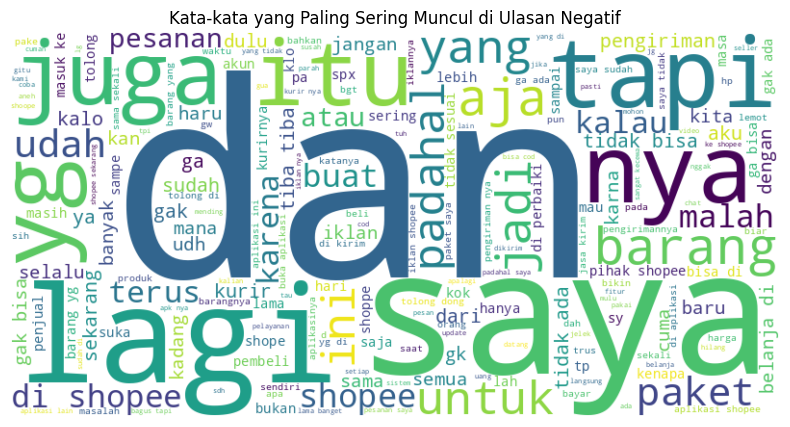

In [15]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Ambil hanya ulasan yang negatif
negative_text = " ".join(clean_df[clean_df['sentiment'] == 'Negative']['content'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(negative_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Kata-kata yang Paling Sering Muncul di Ulasan Negatif")
plt.show()

,count
sentiment,
Negative,10188
Positive,6376
Neutral,2009


/tmp/ipykernel_2172/1556481133.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')


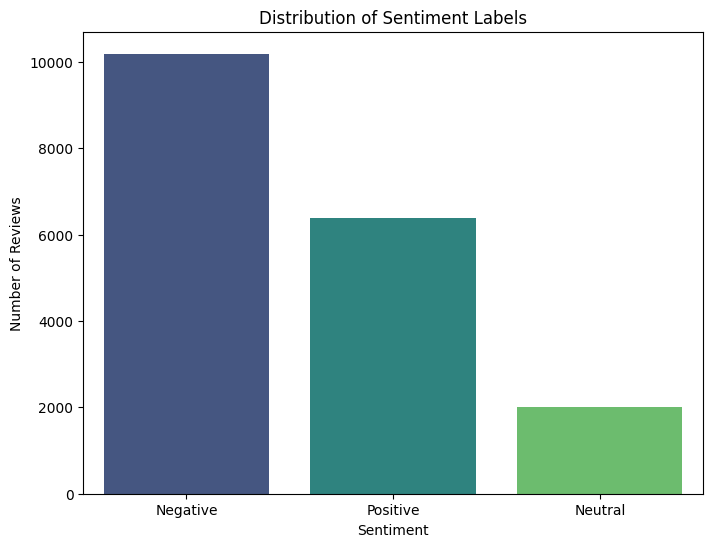

In [16]:
# Menghitung jumlah ulasan untuk setiap kategori sentimen
sentiment_counts = clean_df['sentiment'].value_counts()
display(sentiment_counts)

# Memvisualisasikan distribusi sentimen
plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

#Eksplorasi Label

# Data Splitting dan Ekstraksi Fitur dengN TF-IDF

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. PROSES TF-IDF (Ini yang tadi terlewat/belum terdefinisi)
# TF-IDF butuh teks dalam bentuk string
text_samples = clean_df['text_akhir'].astype(str)

tfidf_vectorizer = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1, 2),
    min_df=2
)

# Membuat matriks X_tfidf
X_tfidf = tfidf_vectorizer.fit_transform(text_samples).toarray()

# 2. SIAPKAN KOMPONEN LAIN
y = clean_df['sentiment']
X_indobert = np.stack(clean_df['embedding'].values)
indobert_score = clean_df['confidence_score'].values.reshape(-1, 1)

# 3. GABUNGKAN (Sekarang X_tfidf sudah ada)
# Gabungkan TF-IDF (2000) + IndoBERT Embedding (768) + Score (1)
X_combined_tfidf = np.hstack((X_tfidf, X_indobert, indobert_score))

# 4. SPLIT DATA
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    X_combined_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

# 5. SMOTE
smote_tfidf = SMOTE(random_state=42)
X_train_res_tfidf, y_train_res_tfidf = smote_tfidf.fit_resample(X_train_tfidf, y_train_tfidf)

print(f"Skenario TF-IDF + Embedding Siap!")
print(f"Jumlah Fitur Total: {X_train_res_tfidf.shape[1]}")
print(f"Distribusi setelah SMOTE: {Counter(y_train_res_tfidf)}")

Skenario TF-IDF + Embedding Siap!
Jumlah Fitur Total: 2769
Distribusi setelah SMOTE: Counter({'Negative': 8150, 'Positive': 8150, 'Neutral': 8150})


### Membuat Fitur Word2Vec

Langkah ini akan menghasilkan representasi vektor untuk setiap ulasan menggunakan model Word2Vec yang dilatih dari data teks yang sudah dibersihkan.

In [18]:
# Install gensim if not already installed
!pip install gensim
import numpy as np
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter


# 1. Pastikan data adalah list of words (Tokenized)
# Kita pecah string 'text_akhir' menjadi list kata agar Word22Vec tidak belajar per huruf
word2vec_data = [text.split() for text in clean_df['text_akhir'].astype(str).tolist()]

# 2. Latih Ulang Model Word2Vec dengan benar
print("Melatih ulang model Word2Vec (Kata per Kata)...")
model_w2v = Word2Vec(sentences=word2vec_data, vector_size=300, window=5, min_count=5, workers=4, seed=42)

# 3. Fungsi Document Vector (Sama seperti sebelumnya)
def document_vector(word_list, model):
    vectors = [model.wv[word] for word in word_list if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

# 4. Buat fitur X_w2v (300 fitur)
X_w2v = np.array([document_vector(words, model_w2v) for words in word2vec_data])

# 5. Siapkan Fitur Pendukung (IndoBERT)
X_indobert = np.stack(clean_df['embedding'].values) # 768 fitur
indobert_score = clean_df['confidence_score'].values.reshape(-1, 1) # 1 fitur

# 6. GABUNGKAN SEMUANYA (Total 1069 Fitur)
X_combined_w2v = np.hstack((X_w2v, X_indobert, indobert_score))

print(f"Hasil Akhir X_combined_w2v: {X_combined_w2v.shape}")

Melatih ulang model Word2Vec (Kata per Kata)...
Hasil Akhir X_combined_w2v: (18573, 1069)


In [19]:
# 1. Split Data
y = clean_df['sentiment']
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(
    X_combined_w2v, y, test_size=0.2, random_state=42, stratify=y
)

# 2. SMOTE
print("Menjalankan SMOTE untuk Skenario Word2Vec...")
smote_w2v = SMOTE(random_state=42)
X_train_res_w2v, y_train_res_w2v = smote_w2v.fit_resample(X_train_w2v, y_train_w2v)

print("\n--- STATUS FINAL SKENARIO WORD2VEC ---")
print(f"Jumlah Fitur: {X_train_res_w2v.shape[1]}")
print(f"Distribusi Kelas: {Counter(y_train_res_w2v)}")

Menjalankan SMOTE untuk Skenario Word2Vec...

--- STATUS FINAL SKENARIO WORD2VEC ---
Jumlah Fitur: 1069
Distribusi Kelas: Counter({'Negative': 8150, 'Positive': 8150, 'Neutral': 8150})


# Modeling Menggunakan TF IDF

In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded_tfidf = le.fit_transform(y_train_res_tfidf)
y_test_encoded_tfidf = le.transform(y_test_tfidf)

# Catatan:
# 0 biasanya Negative, 1 Neutral, 2 Positive (tergantung urutan abjad)
print("Urutan kelas:", le.classes_)

Urutan kelas: ['Negative' 'Neutral' 'Positive']


In [21]:
from sklearn.utils import class_weight
import numpy as np

# Hitung bobot kelas dari y_train_res_tfidf (data latih setelah SMOTE)
# Jika ingin bobot berdasarkan frekuensi (default 'balanced'), gunakan y_train_res_tfidf
# Jika ingin semua kelas memiliki bobot sama setelah SMOTE, bisa diatur secara manual.
# Namun, 'balanced' di sini akan menghitung bobot berdasarkan rasio kebalikan frekuensi di y_train_res_tfidf,
# yang mana seharusnya sama untuk semua kelas karena sudah di-SMOTE.
# Atau, kita bisa menghitungnya dari `y_train_tfidf` (sebelum SMOTE) untuk kasus khusus.

# Mari kita coba menghitung bobot berdasarkan y_train_res_tfidf, yang seharusnya menghasilkan bobot hampir sama (1)
# karena kelas-kelasnya sudah seimbang.
class_weights_balanced = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_res_tfidf),
    y=y_train_res_tfidf
)

# Mengonversi array bobot ke dictionary dengan label asli
le_classes = le.classes_
class_weight_dict = {le_classes[i]: class_weights_balanced[i] for i in range(len(le_classes))}

print("Bobot kelas yang dihitung (setelah SMOTE):", class_weight_dict)

# Jika ingin bobot dari data sebelum SMOTE (untuk menekankan minoritas asli)
class_weights_pre_smote = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_tfidf),
    y=y_train_tfidf
)
class_weight_dict_pre_smote = {le_classes[i]: class_weights_pre_smote[i] for i in range(len(le_classes))}
print("Bobot kelas yang dihitung (sebelum SMOTE):", class_weight_dict_pre_smote)

Bobot kelas yang dihitung (setelah SMOTE): {'Negative': np.float64(1.0), 'Neutral': np.float64(1.0), 'Positive': np.float64(1.0)}
Bobot kelas yang dihitung (sebelum SMOTE): {'Negative': np.float64(0.6076891615541923), 'Neutral': np.float64(3.081933208877826), 'Positive': np.float64(0.970920734496504)}


In [22]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# 1. Buat `sample_weight` berdasarkan `class_weight_dict_pre_smote`
# Pertama, kita perlu mengubah label numerik kembali ke label string untuk mencari bobotnya
y_train_res_tfidf_labels = le.inverse_transform(y_train_encoded_tfidf)

sample_weights_xgb = np.array([
    class_weight_dict_pre_smote[label] for label in y_train_res_tfidf_labels
])

print("Sample weights created. Shape:", sample_weights_xgb.shape)

# 2. Inisialisasi Model XGBoost
xgb_model_tfidf_weighted = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.02,
    max_depth=8,
    gamma=0.2,
    subsample=0.8,
    colsample_bytree=0.7,
    objective='multi:softprob',
    num_class=3,
    random_state=42,
    n_jobs=-1,
    tree_method='hist',     # Ganti ke 'gpu_hist' jika pakai GPU Colab
    device='cuda'           # Tambahkan ini jika pakai GPU
)

# 3. Training dengan `sample_weight` dan monitoring
xgb_model_tfidf_weighted.fit(
    X_train_res_tfidf, y_train_encoded_tfidf,
    sample_weight=sample_weights_xgb, # Menerapkan sample_weight di sini
    eval_set=[(X_test_tfidf, y_test_encoded_tfidf)],
    verbose=100
)

# 4. PREDIKSI DATA TESTING ---
y_pred_test_xgb_weighted = xgb_model_tfidf_weighted.predict(X_test_tfidf)

# 5. HITUNG AKURASI ---
acc_test_xgb_weighted = accuracy_score(y_test_encoded_tfidf, y_pred_test_xgb_weighted)

# 6. TAMPILKAN HASIL ---
print("="*70)
print(f"{'HASIL PERFORMA MODEL XGBOOST (TF-IDF + SAMPLE WEIGHTS)':^70}")
print("="*70)
print(f"Akurasi Data Testing (Unseen) : {acc_test_xgb_weighted:.4f} ({acc_test_xgb_weighted*100:.2f}%) ")
print("-"*70)

print("\n[ Laporan Klasifikasi DATA TESTING ]")
print(classification_report(y_test_encoded_tfidf, y_pred_test_xgb_weighted, target_names=le.classes_))
print("="*70)

Sample weights created. Shape: (24450,)
[0]	validation_0-mlogloss:1.64496
[100]	validation_0-mlogloss:0.34256
[200]	validation_0-mlogloss:0.20352
[300]	validation_0-mlogloss:0.17295
[400]	validation_0-mlogloss:0.16255
[500]	validation_0-mlogloss:0.15768
[600]	validation_0-mlogloss:0.15525
[700]	validation_0-mlogloss:0.15373
[800]	validation_0-mlogloss:0.15265
[900]	validation_0-mlogloss:0.15218
[1000]	validation_0-mlogloss:0.15189
[1100]	validation_0-mlogloss:0.15166
[1200]	validation_0-mlogloss:0.15145
[1300]	validation_0-mlogloss:0.15149
[1400]	validation_0-mlogloss:0.15141
[1500]	validation_0-mlogloss:0.15131
[1600]	validation_0-mlogloss:0.15126
[1700]	validation_0-mlogloss:0.15123
[1800]	validation_0-mlogloss:0.15123
[1900]	validation_0-mlogloss:0.15126
[1999]	validation_0-mlogloss:0.15121


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [07:11:01] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


        HASIL PERFORMA MODEL XGBOOST (TF-IDF + SAMPLE WEIGHTS)        
Akurasi Data Testing (Unseen) : 0.9384 (93.84%) 
----------------------------------------------------------------------

[ Laporan Klasifikasi DATA TESTING ]
              precision    recall  f1-score   support

    Negative       0.97      0.94      0.96      2038
     Neutral       0.71      0.92      0.80       402
    Positive       0.97      0.94      0.96      1275

    accuracy                           0.94      3715
   macro avg       0.89      0.93      0.91      3715
weighted avg       0.95      0.94      0.94      3715



In [23]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, accuracy_score

# Ubah class_weight_dict agar key-nya berupa integer
class_weight_encoded = {le.transform([k])[0]: v for k, v in class_weight_dict_pre_smote.items()}
# 1. Inisialisasi Model
lgbm_model_tfidf = LGBMClassifier(
    n_estimators=1200,
    learning_rate=0.03,
    num_leaves=150,
    max_depth=12,
    min_child_samples=20,    # Sama dengan min_data_in_leaf
    colsample_bytree=0.8,    # Sama dengan feature_fraction
    importance_type='gain',  # Agar feature importance lebih akurat
    force_col_wise=True,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,             # Menghilangkan warning yang tidak perlu
    class_weight=class_weight_encoded # Menggunakan bobot dari data sebelum SMOTE

)

# 2. Training dengan monitoring
# Kita sisipkan eval_set untuk melihat performa selama training
lgbm_model_tfidf.fit(
    X_train_res_tfidf, y_train_encoded_tfidf,
    eval_set=[(X_test_tfidf, y_test_encoded_tfidf)],
    eval_metric='multi_logloss'
)

# 3. PREDIKSI DATA TRAINING & TESTING ---
y_pred_test_lgbm = lgbm_model_tfidf.predict(X_test_tfidf)

# 4. HITUNG AKURASI ---
acc_test_lgbm = accuracy_score(y_test_encoded_tfidf, y_pred_test_lgbm)

# 5. TAMPILKAN HASIL ---
print("="*65)
print(f"{'HASIL PERFORMA MODEL LIGHTGBM':^65}")
print("="*65)
print(f"Akurasi Data Testing (Unseen) : {acc_test_lgbm:.4f} ({acc_test_lgbm*100:.2f}%)")
print("-"*65)



print("\n[ Laporan Klasifikasi DATA TESTING ]")
print(classification_report(y_test_encoded_tfidf, y_pred_test_lgbm, target_names=le.classes_))
print("="*65)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


                  HASIL PERFORMA MODEL LIGHTGBM                  
Akurasi Data Testing (Unseen) : 0.9459 (94.59%)
-----------------------------------------------------------------

[ Laporan Klasifikasi DATA TESTING ]
              precision    recall  f1-score   support

    Negative       0.97      0.96      0.96      2038
     Neutral       0.77      0.89      0.82       402
    Positive       0.97      0.94      0.96      1275

    accuracy                           0.95      3715
   macro avg       0.90      0.93      0.92      3715
weighted avg       0.95      0.95      0.95      3715



# Modeling Menggunakan Word2Vec

In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded_word2vec = le.fit_transform(y_train_res_w2v)
y_test_encoded_word2vec = le.transform(y_test_w2v)

# Catatan:
# 0 biasanya Negative, 1 Neutral, 2 Positive (tergantung urutan abjad)
print("Urutan kelas:", le.classes_)

Urutan kelas: ['Negative' 'Neutral' 'Positive']


In [25]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Pastikan y_train_w2v (sebelum SMOTE) digunakan untuk menghitung class_weight_dict_pre_smote
# Jika le.classes_ sama dengan yang digunakan di TF-IDF, kita bisa pakai class_weight_dict_pre_smote yang sudah dihitung sebelumnya.
# Jika tidak, kita perlu menghitung ulang dari y_train_w2v. Asumsi saat ini le.classes_ sama.

# 1. Buat `sample_weight` berdasarkan `class_weight_dict_pre_smote`
y_train_res_w2v_labels = le.inverse_transform(y_train_encoded_word2vec)

sample_weights_xgb_w2v = np.array([
    class_weight_dict_pre_smote[label] for label in y_train_res_w2v_labels
])

print("Sample weights created for Word2Vec XGBoost. Shape:", sample_weights_xgb_w2v.shape)

# 2. Inisialisasi Model XGBoost
xgb_model_w2v_weighted = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.02,
    max_depth=8,
    gamma=0.2,
    subsample=0.8,
    colsample_bytree=0.7,
    objective='multi:softprob',
    num_class=3,
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    device='cuda'
)

# 3. Training dengan `sample_weight` dan monitoring
xgb_model_w2v_weighted.fit(
    X_train_res_w2v, y_train_encoded_word2vec,
    sample_weight=sample_weights_xgb_w2v, # Menerapkan sample_weight di sini
    eval_set=[(X_test_w2v, y_test_encoded_word2vec)],
    verbose=100
)

# 4. PREDIKSI DATA TESTING ---
y_pred_test_xgb_w2v_weighted = xgb_model_w2v_weighted.predict(X_test_w2v)

# 5. HITUNG AKURASI ---
acc_test_xgb_w2v_weighted = accuracy_score(y_test_encoded_word2vec, y_pred_test_xgb_w2v_weighted)

# 6. TAMPILKAN HASIL ---
print("\n" + "="*70)
print(f"{'HASIL PERFORMA MODEL XGBOOST (WORD2VEC + SAMPLE WEIGHTS)':^70}")
print("="*70)
print(f"Akurasi Data Testing (Unseen) : {acc_test_xgb_w2v_weighted:.4f} ({acc_test_xgb_w2v_weighted*100:.2f}%) ")
print("-"*70)

print("\n[ Laporan Klasifikasi DATA TESTING ]")
print(classification_report(y_test_encoded_word2vec, y_pred_test_xgb_w2v_weighted, target_names=le.classes_))
print("="*70)

Sample weights created for Word2Vec XGBoost. Shape: (24450,)
[0]	validation_0-mlogloss:1.64509
[100]	validation_0-mlogloss:0.34196
[200]	validation_0-mlogloss:0.20337
[300]	validation_0-mlogloss:0.17316
[400]	validation_0-mlogloss:0.16292
[500]	validation_0-mlogloss:0.15817
[600]	validation_0-mlogloss:0.15541
[700]	validation_0-mlogloss:0.15394
[800]	validation_0-mlogloss:0.15284
[900]	validation_0-mlogloss:0.15234
[1000]	validation_0-mlogloss:0.15201
[1100]	validation_0-mlogloss:0.15176
[1200]	validation_0-mlogloss:0.15160
[1300]	validation_0-mlogloss:0.15161
[1400]	validation_0-mlogloss:0.15152
[1500]	validation_0-mlogloss:0.15146
[1600]	validation_0-mlogloss:0.15138
[1700]	validation_0-mlogloss:0.15132
[1800]	validation_0-mlogloss:0.15130
[1900]	validation_0-mlogloss:0.15132
[1999]	validation_0-mlogloss:0.15126

       HASIL PERFORMA MODEL XGBOOST (WORD2VEC + SAMPLE WEIGHTS)       
Akurasi Data Testing (Unseen) : 0.9400 (94.00%) 
-----------------------------------------------------

### Penerapan `class_weight` pada LightGBM (Word2Vec Features)

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, accuracy_score
import lightgbm as lgb

# Asumsi: 'le' adalah LabelEncoder yang Anda gunakan sebelumnya
class_weight_encoded = {le.transform([k])[0]: v for k, v in class_weight_dict_pre_smote.items()}
# 1. Inisialisasi Model dengan class_weight
lgbm_model_w2v_weighted = LGBMClassifier(
    n_estimators=1000,        # Dikurangi dari 2000 (Early stopping akan menjaga akurasi)
    learning_rate=0.05,       # Dinaikkan dari 0.02 agar konvergen lebih cepat
    num_leaves=31,            # KUNCI KECEPATAN: Default 31 jauh lebih cepat daripada 128
    max_depth=8,              # Dibatasi agar pohon tidak terlalu kompleks
    min_child_samples=30,
    subsample=0.8,
    subsample_freq=5,
    colsample_bytree=0.8,
    force_col_wise=True,
    random_state=42,
    n_jobs=-1,
    verbosity=1,
    class_weight=class_weight_encoded # Menggunakan bobot dari data sebelum SMOTE
)

# 2. Training dengan Early Stopping yang lebih agresif
lgbm_model_w2v_weighted.fit(
    X_train_res_w2v, y_train_encoded_word2vec,
    eval_set=[(X_test_w2v, y_test_encoded_word2vec)],
    eval_metric='multi_logloss',
    callbacks=[
        lgb.early_stopping(stopping_rounds=30),
        lgb.log_evaluation(period=50)
    ]
)

# PREDIKSI DATA TRAINING & TESTING ---
y_pred_test_lgbm_w2v_weighted = lgbm_model_w2v_weighted.predict(X_test_w2v)

# HITUNG AKURASI ---
acc_test_lgbm_w2v_weighted = accuracy_score(y_test_encoded_word2vec, y_pred_test_lgbm_w2v_weighted)

# TAMPILKAN HASIL ---
print("="*70)
print(f"{'HASIL PERFORMA LIGHTGBM (WORD2VEC + CLASS WEIGHTS)':^70}")
print("="*70)
print(f"Akurasi Data Testing (Unseen) : {acc_test_lgbm_w2v_weighted:.4f} ({acc_test_lgbm_w2v_weighted*100:.2f}%) ")
print(f"Best Iteration                : {lgbm_model_w2v_weighted.best_iteration_}")
print("-"*70)


print("\n[ Laporan Klasifikasi DATA TESTING ]")
print(classification_report(y_test_encoded_word2vec, y_pred_test_lgbm_w2v_weighted, target_names=le.classes_))
print("="*70)

#Testing

In [33]:
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel

# --- 1. SETTING DEVICE (GPU/CPU) ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. LOAD INDOBERT COMPONENTS ---
# Pastikan koneksi internet aktif untuk download (jika belum ada di cache)
model_name = "indobenchmark/indobert-base-p1"
tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name).to(device)
bert_model.eval()

def get_bert_embedding(text):
    """Mengubah teks menjadi vektor 768 dimensi menggunakan IndoBERT"""
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128).to(device)
    with torch.no_grad():
        outputs = bert_model(**inputs)
    # Mean Pooling
    return outputs.last_hidden_state.mean(dim=1).cpu().numpy()

# --- FUNGSI PREPROCESSING LENGKAP ---
def full_preprocessing(text):
    text = cleaningText(text)
    text = casefoldingText(text)
    text = reduce_lengthening(text)
    text = fix_slangwords(text)
    text = handle_negation(text)
    text_tokens = tokenizingText(text)
    text_filtered = filteringText(text_tokens)
    return toSentence(text_filtered)

# --- 3. FUNGSI PREDIKSI HYBRID ---
def prediksi_sentimen_hybrid_final(ulasan_user):
    try:
        # TAHAP A: Preprocessing
        teks_bersih = full_preprocessing(ulasan_user)

        if not teks_bersih.strip():
            return "Teks kosong.", 0, ulasan_user, [0,0,0]

        # TAHAP B: Ekstraksi TF-IDF (2000 fitur)
        v_tfidf = tfidf_vectorizer.transform([teks_bersih]).toarray()

        # TAHAP C: Ekstraksi BERT (768 fitur)
        v_bert = get_bert_embedding(teks_bersih)

        # TAHAP D: Penggabungan (Horizontal Stack)
        # 2000 (TF-IDF) + 768 (BERT) = 2768
        X_input = np.hstack([v_tfidf, v_bert])

        # TAHAP E: Penanganan Mismatch (Fitur ke-2769)
        # Menambahkan satu kolom nol di akhir agar pas 2769 sesuai modelmu
        # Note: Ini hanya jika model dilatih dengan 2769 fitur dan input sekarang 2768.
        # Periksa X_train_res_tfidf.shape[1] dari training model.
        if X_input.shape[1] < xgb_model_tfidf_weighted.n_features_in_:
            padding = np.zeros((X_input.shape[0], xgb_model_tfidf_weighted.n_features_in_ - X_input.shape[1]))
            X_input = np.hstack([X_input, padding])

        # TAHAP F: Prediksi Skor menggunakan model yang sudah di-weighted
        prob = xgb_model_tfidf_weighted.predict_proba(X_input)[0]
        idx = np.argmax(prob)

        label = le.inverse_transform([idx])[0]
        confidence = prob[idx] * 100

        return label, confidence, teks_bersih, prob

    except Exception as e:
        return f"Terjadi kesalahan: {str(e)}", 0, "", [0,0,0]

# --- 4. INTERFACE PROGRAM ---
print("\n" + "="*65)
print(f"{'APLIKASI SENTIMEN SHOPEE HYBRID (XGBOOST + BERT)':^65}")
print(f"{'STATUS DEVICE: ' + str(device).upper():^65}")
print("="*65)
print("Petunjuk: Masukkan ulasan atau ketik 'keluar' untuk berhenti.")

while True:
    ulasan = input("\nMasukkan ulasan: ")

    if ulasan.lower() == 'keluar':
        print("Program selesai. Sampai jumpa!")
        break

    hasil_label, skor, bersih, prob_all = prediksi_sentimen_hybrid_final(ulasan)

    if skor > 0:
        print(f"\n[ HASIL ANALISIS ]")
        print(f"Teks Bersih : {bersih}")
        print(f"Sentimen    : {hasil_label.upper()} ({skor:.2f}%)")

        # Detail Probabilitas
        detail = {le.classes_[i]: f"{prob_all[i]*100:.1f}%" for i in range(len(le.classes_))}
        print(f"Probabilitas: {detail}")

        # Ikon Visual
        icon = "🟢" if hasil_label.lower() == 'positive' else "🔴" if hasil_label.lower() == 'negative' else "🟡"
        print(f"Indikator   : {icon}")
    else:
        print(f"\n⚠️ {hasil_label}")

    print("-" * 65)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


        APLIKASI SENTIMEN SHOPEE HYBRID (XGBOOST + BERT)         
                       STATUS DEVICE: CUDA                       
Petunjuk: Masukkan ulasan atau ketik 'keluar' untuk berhenti.

Masukkan ulasan: koneksinya padahal bagus tapi susah banget buat masuk aplikasi sama lelet banget sedangkan di aplikasi lain berjalan normal, setelah saya cek sistem dan ruang penyimpanannya pun bagus hp saya normal semua cuman 1 aplikasi ini yg susah untuk di buka dan kinerja lambat, padahal semuanya aman, apapun solusinya intinya harus di tangani masalahnya!.

[ HASIL ANALISIS ]
Teks Bersih : koneksinya bagus susah banget masuk lelet banget berjalan normal cek sistem ruang penyimpanannya bagus hp normal cuman susah buka kinerja lambat aman apapun solusinya intinya tangani
Sentimen    : NEGATIVE (38.27%)
Probabilitas: {'Negative': '38.3%', 'Neutral': '27.8%', 'Positive': '33.9%'}
Indikator   : 🔴
-----------------------------------------------------------------

Masukkan ulasan: Saya cukup ter

In [34]:
!pip freeze > requirements.txt